STUDENT PLACEMENT DATASET
   CGPA  AptitudeScore  TechnicalScore  CommunicationScore Internship Branch  \
0   6.2             45              40                  50         No    CSE   
1   6.5             50              45                  52         No    ECE   
2   6.8             52              48                  55         No    CSE   
3   7.0             55              52                  58        Yes     IT   
4   7.2             58              55                  60         No    ECE   

  PlacementStatus  
0      Not Placed  
1      Not Placed  
2      Not Placed  
3          Placed  
4      Not Placed  

Dataset Shape:
(30, 7)

FEATURE TYPES
Numerical Features:
['CGPA', 'AptitudeScore', 'TechnicalScore', 'CommunicationScore']

Categorical Features:
['Internship', 'Branch']

TRAIN / VALIDATION SPLIT
Training samples: 24
Validation samples: 6

DECISION TREE - GINI
Train Accuracy: 1.0
Validation Accuracy: 1.0

Classification Report:
              precision    recall  f1-sc

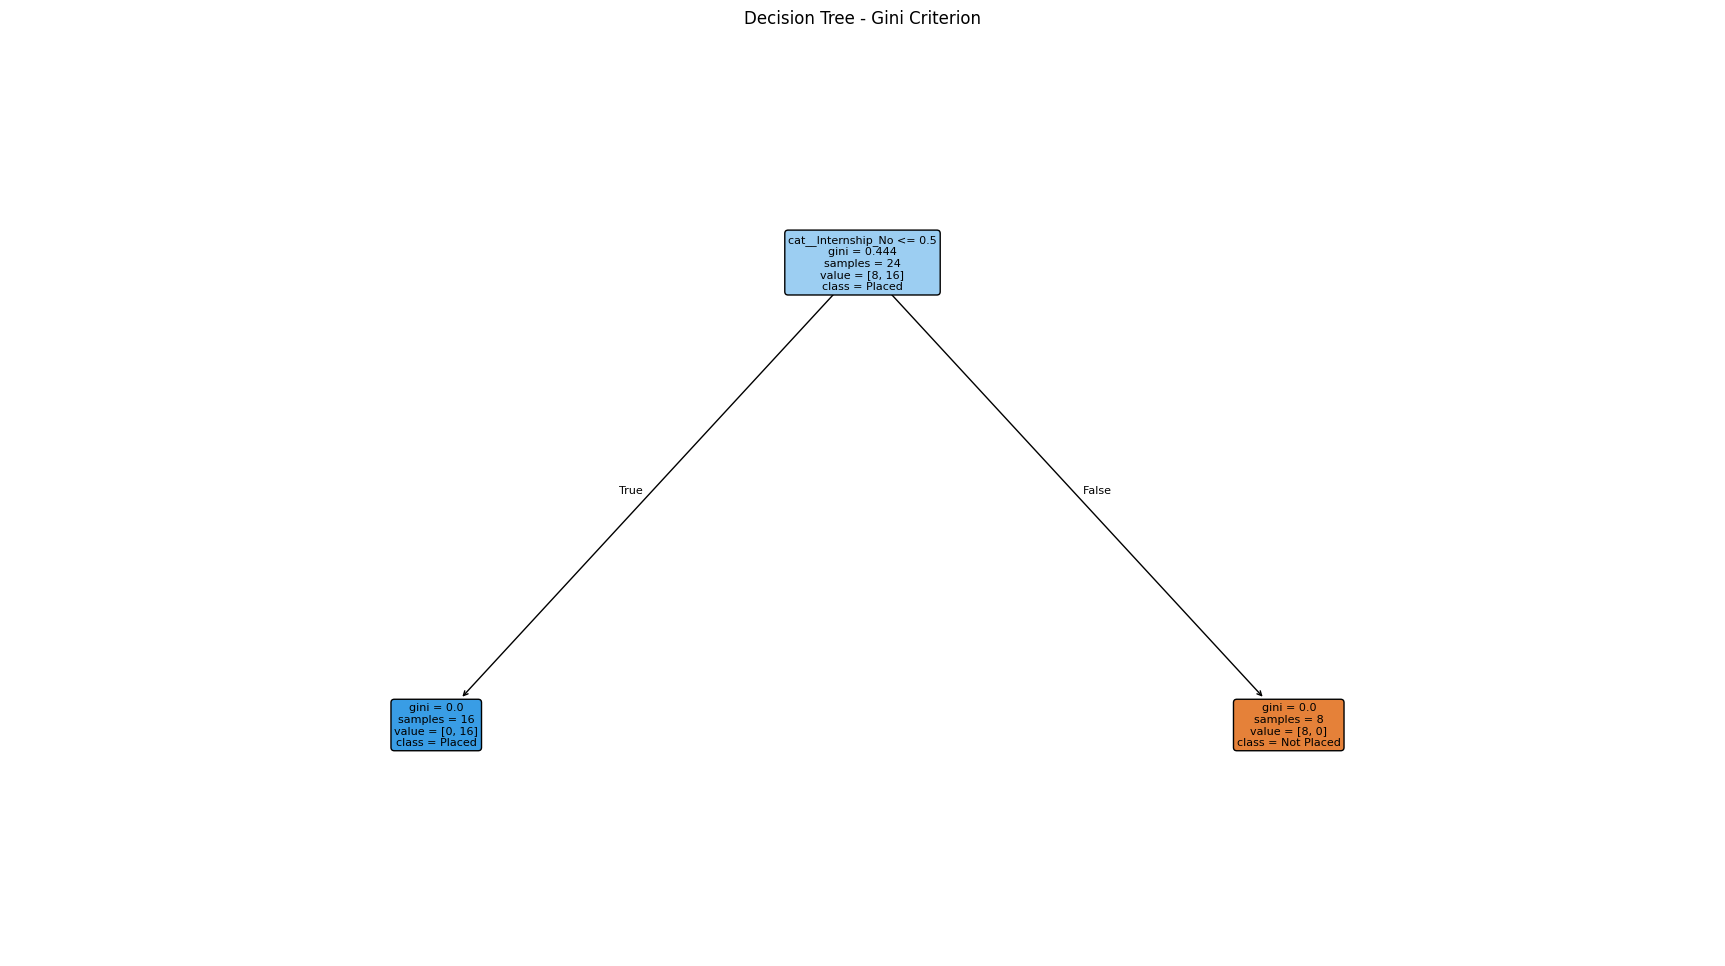



COST-COMPLEXITY PRUNING PATH
Number of CCP alpha values: 2


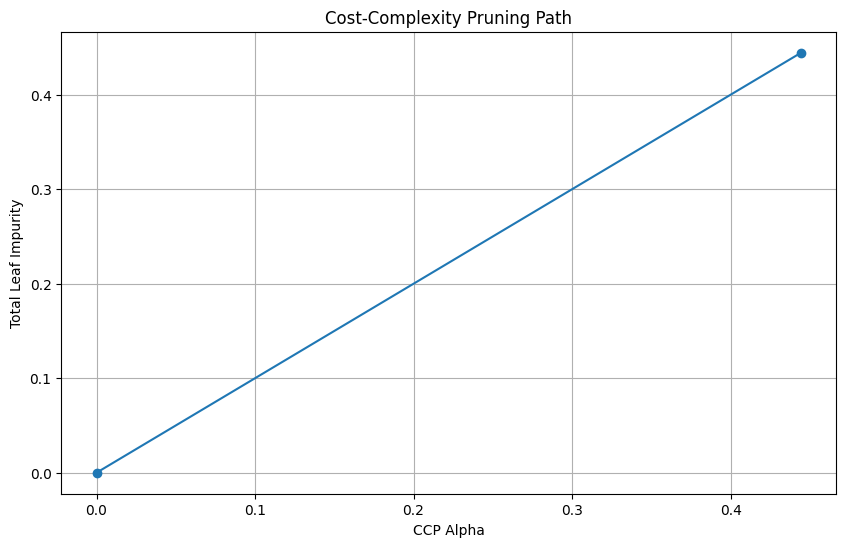

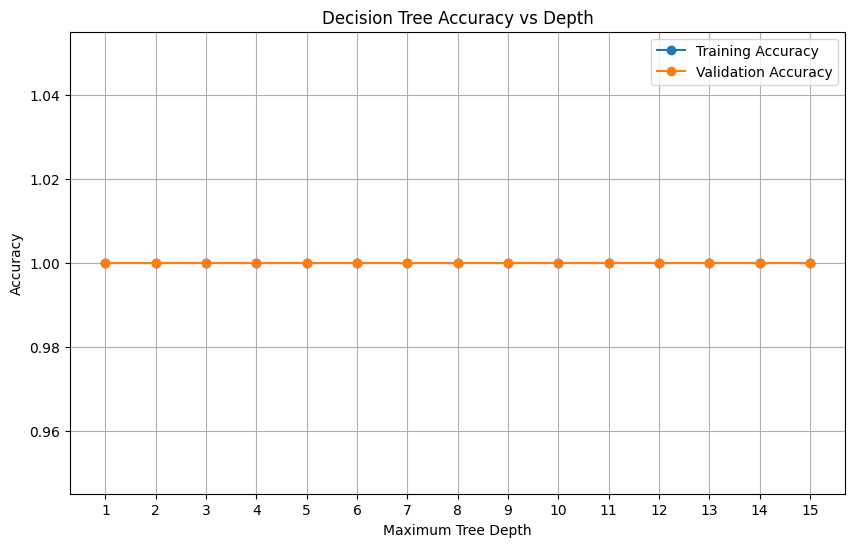



BEST DECISION TREE DEPTH
depth        1.0
train_acc    1.0
val_acc      1.0
n_leaves     2.0


DECISION TREE DEPTH REPORT
 depth  train_acc  val_acc  n_leaves
     1        1.0      1.0         2
     2        1.0      1.0         2
     3        1.0      1.0         2
     4        1.0      1.0         2
     5        1.0      1.0         2
     6        1.0      1.0         2
     7        1.0      1.0         2
     8        1.0      1.0         2
     9        1.0      1.0         2
    10        1.0      1.0         2
    11        1.0      1.0         2
    12        1.0      1.0         2
    13        1.0      1.0         2
    14        1.0      1.0         2
    15        1.0      1.0         2

Best depth from validation: 1


FINAL DECISION TREE
Best Depth: 1
Train Accuracy: 1.0
Validation Accuracy: 1.0

Number of Leaves: 2


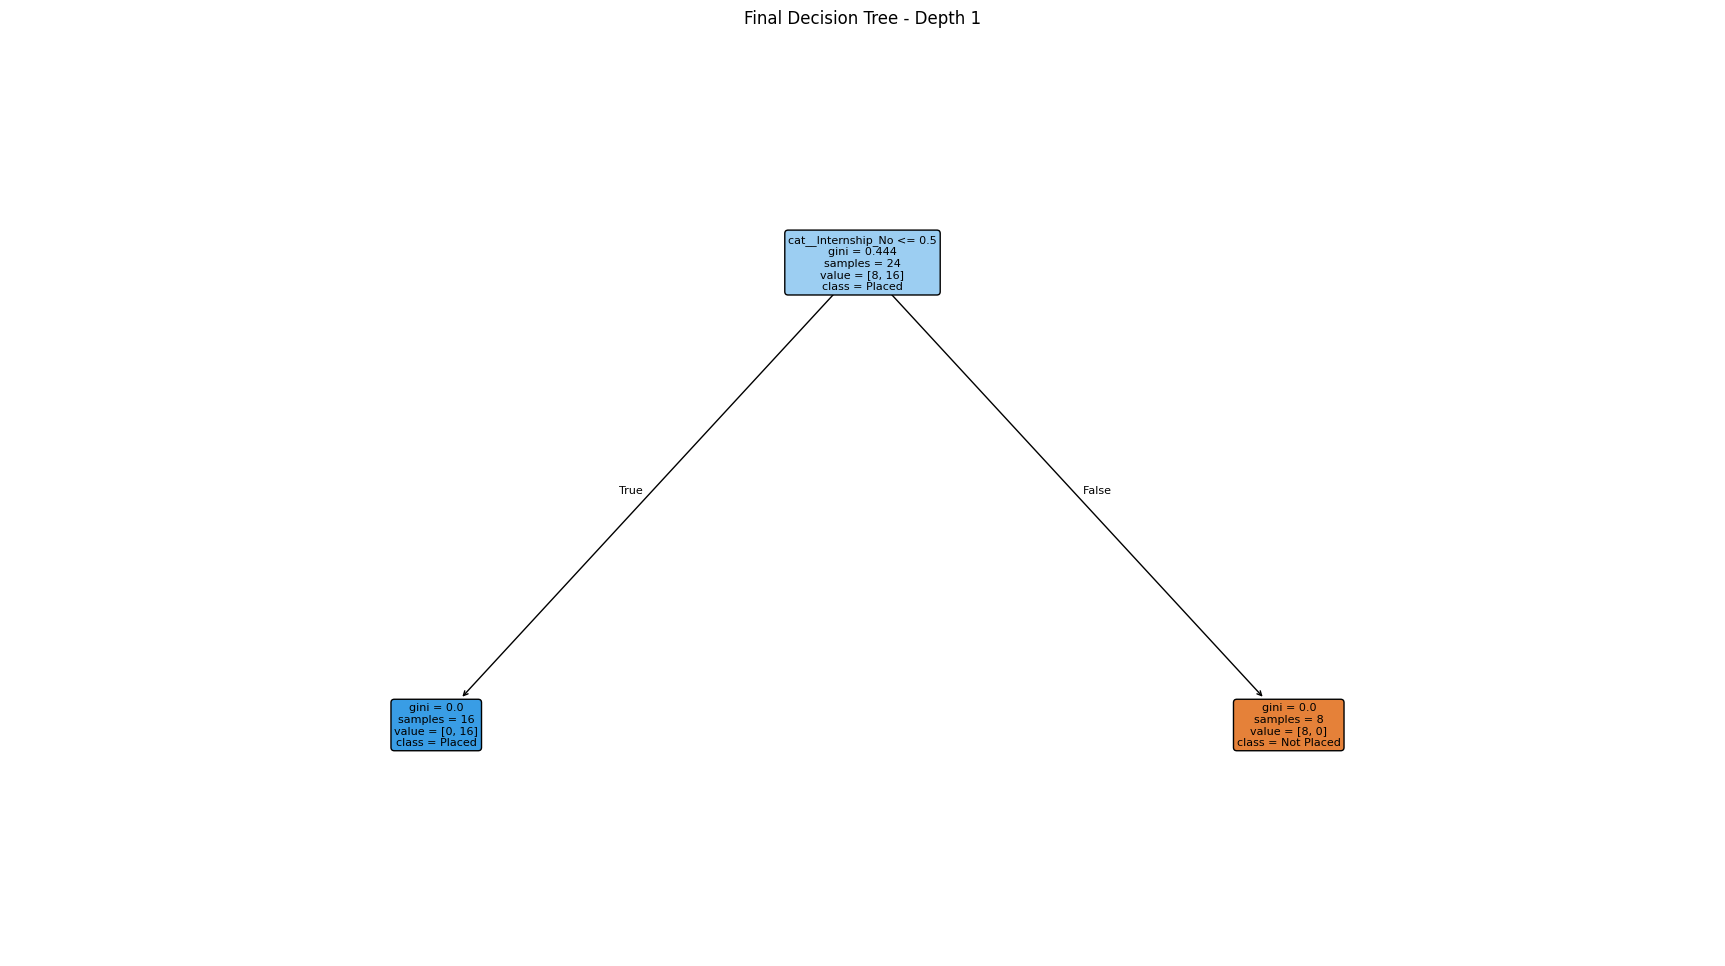



FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00         2
      Placed       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



SESSION 6 ANALYSIS

1. A Decision Tree classifier was implemented for student
   placement prediction.

2. One-Hot Encoding was used for categorical variables.

3. Gini impurity and Entropy were compared as splitting
   criteria.

4. plot_tree() was used to visualize the decision tree.

5. Cost-complexity pruning was analyzed using CCP alpha values.

6. Decision tree depth was tested from 1 to 15.

7. Training accuracy, validation accuracy and number of
   leaves were recorded.

8. dt_report() returns a DataFrame containing:
      depth
      train_acc
      val_acc
      n_leaves

9. Training and validation accuracy were plotted aga

In [1]:
# ================================================================
# MACHINE LEARNING PRACTICAL - SESSION 6
# ================================================================
# TOPIC:
# Decision Tree Classification
#
# Includes:
# 1. Decision Tree using Gini
# 2. Decision Tree using Entropy
# 3. plot_tree() visualization
# 4. Gini vs Entropy comparison
# 5. CCP pruning path
# 6. max_depth sweep from 1 to 15
# 7. dt_report() function
# 8. Train and validation accuracy
# 9. Number of leaves
# 10. Accuracy curves
# ================================================================


# ----------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ----------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.metrics import (
    accuracy_score,
    classification_report
)


# =================================================================
# 2. CREATE DATASET
# =================================================================
# We are creating the dataset directly inside Google Colab.
# No external CSV or dataset is required.
#
# Features:
# CGPA
# AptitudeScore
# TechnicalScore
# CommunicationScore
# Internship
# Branch
#
# Target:
# PlacementStatus
# =================================================================


data = {

    'CGPA': [
        6.2, 6.5, 6.8, 7.0, 7.2,
        7.4, 7.6, 7.8, 8.0, 8.2,
        8.4, 8.6, 8.8, 9.0, 9.2,
        9.4, 6.1, 6.7, 7.1, 7.5,
        7.9, 8.3, 8.7, 9.1, 6.4,
        6.9, 7.3, 7.7, 8.1, 8.5
    ],

    'AptitudeScore': [
        45, 50, 52, 55, 58,
        60, 62, 65, 68, 70,
        72, 75, 78, 80, 85,
        88, 42, 48, 56, 61,
        67, 73, 77, 83, 46,
        54, 59, 64, 71, 76
    ],

    'TechnicalScore': [
        40, 45, 48, 52, 55,
        58, 60, 64, 67, 70,
        72, 76, 79, 82, 86,
        90, 38, 44, 50, 57,
        63, 69, 75, 84, 43,
        49, 55, 62, 68, 74
    ],

    'CommunicationScore': [
        50, 52, 55, 58, 60,
        62, 65, 67, 70, 72,
        74, 76, 79, 82, 85,
        88, 48, 54, 57, 61,
        64, 68, 73, 80, 51,
        56, 59, 63, 69, 75
    ],

    'Internship': [
        'No', 'No', 'No', 'Yes', 'No',
        'Yes', 'Yes', 'No', 'Yes', 'Yes',
        'Yes', 'Yes', 'Yes', 'Yes', 'Yes',
        'Yes', 'No', 'No', 'No', 'Yes',
        'Yes', 'Yes', 'Yes', 'Yes', 'No',
        'No', 'Yes', 'Yes', 'Yes', 'Yes'
    ],

    'Branch': [
        'CSE', 'ECE', 'CSE', 'IT', 'ECE',
        'CSE', 'IT', 'CSE', 'ECE', 'CSE',
        'IT', 'CSE', 'ECE', 'CSE', 'IT',
        'CSE', 'ECE', 'CSE', 'IT', 'ECE',
        'CSE', 'IT', 'CSE', 'ECE', 'IT',
        'CSE', 'ECE', 'IT', 'CSE', 'CSE'
    ],

    'PlacementStatus': [
        'Not Placed', 'Not Placed', 'Not Placed',
        'Placed', 'Not Placed', 'Placed',
        'Placed', 'Not Placed', 'Placed',
        'Placed', 'Placed', 'Placed', 'Placed',
        'Placed', 'Placed', 'Placed',
        'Not Placed', 'Not Placed', 'Not Placed',
        'Placed', 'Placed', 'Placed', 'Placed',
        'Placed', 'Not Placed', 'Not Placed',
        'Placed', 'Placed', 'Placed', 'Placed'
    ]
}


# Convert dictionary into DataFrame

df = pd.DataFrame(data)


print("=" * 70)
print("STUDENT PLACEMENT DATASET")
print("=" * 70)

print(df.head())

print("\nDataset Shape:")
print(df.shape)


# =================================================================
# 3. SEPARATE FEATURES AND TARGET
# =================================================================

X = df.drop(
    columns=['PlacementStatus']
)

y = df['PlacementStatus']


# =================================================================
# 4. IDENTIFY FEATURE TYPES
# =================================================================

numerical_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=['object']
).columns.tolist()


print("\n" + "=" * 70)
print("FEATURE TYPES")
print("=" * 70)

print("Numerical Features:")
print(numerical_cols)

print("\nCategorical Features:")
print(categorical_cols)


# =================================================================
# 5. PREPROCESSING
# =================================================================
# Decision Trees do not require feature scaling.
#
# But categorical values such as CSE/ECE/IT must be converted
# into numerical values.
#
# Therefore we use One-Hot Encoding.
# =================================================================


preprocessor = ColumnTransformer(

    transformers=[

        (
            'num',
            'passthrough',
            numerical_cols
        ),

        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_cols
        )
    ]
)


# =================================================================
# 6. TRAIN / VALIDATION SPLIT
# =================================================================


X_train, X_val, y_train, y_val = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)


print("\n" + "=" * 70)
print("TRAIN / VALIDATION SPLIT")
print("=" * 70)

print("Training samples:",
      len(X_train))

print("Validation samples:",
      len(X_val))


# =================================================================
# 7. DECISION TREE USING GINI
# =================================================================
#
# Gini impurity measures how mixed the classes are in a node.
#
# Gini = 0 means the node contains only one class.
# =================================================================


gini_model = Pipeline([

    (
        'preprocessor',
        preprocessor
    ),

    (
        'classifier',
        DecisionTreeClassifier(
            criterion='gini',
            max_depth=5,
            random_state=42
        )
    )
])


# Train

gini_model.fit(
    X_train,
    y_train
)


# Predictions

gini_train_pred = gini_model.predict(
    X_train
)

gini_val_pred = gini_model.predict(
    X_val
)


# Accuracy

gini_train_acc = accuracy_score(
    y_train,
    gini_train_pred
)

gini_val_acc = accuracy_score(
    y_val,
    gini_val_pred
)


print("\n" + "=" * 70)
print("DECISION TREE - GINI")
print("=" * 70)

print("Train Accuracy:",
      gini_train_acc)

print("Validation Accuracy:",
      gini_val_acc)


print("\nClassification Report:")

print(
    classification_report(
        y_val,
        gini_val_pred
    )
)


# =================================================================
# 8. DECISION TREE USING ENTROPY
# =================================================================
#
# Entropy measures the impurity/randomness of a node.
#
# Lower entropy means the node is more pure.
# =================================================================


entropy_model = Pipeline([

    (
        'preprocessor',
        preprocessor
    ),

    (
        'classifier',
        DecisionTreeClassifier(
            criterion='entropy',
            max_depth=5,
            random_state=42
        )
    )
])


# Train

entropy_model.fit(
    X_train,
    y_train
)


# Predictions

entropy_train_pred = entropy_model.predict(
    X_train
)

entropy_val_pred = entropy_model.predict(
    X_val
)


# Accuracy

entropy_train_acc = accuracy_score(
    y_train,
    entropy_train_pred
)

entropy_val_acc = accuracy_score(
    y_val,
    entropy_val_pred
)


print("\n" + "=" * 70)
print("DECISION TREE - ENTROPY")
print("=" * 70)

print("Train Accuracy:",
      entropy_train_acc)

print("Validation Accuracy:",
      entropy_val_acc)


print("\nClassification Report:")

print(
    classification_report(
        y_val,
        entropy_val_pred
    )
)


# =================================================================
# 9. GINI VS ENTROPY COMPARISON
# =================================================================


comparison = pd.DataFrame({

    'Criterion': [
        'Gini',
        'Entropy'
    ],

    'Train Accuracy': [
        gini_train_acc,
        entropy_train_acc
    ],

    'Validation Accuracy': [
        gini_val_acc,
        entropy_val_acc
    ]
})


print("\n")
print("=" * 70)
print("GINI VS ENTROPY")
print("=" * 70)

print(
    comparison.to_string(
        index=False
    )
)


# =================================================================
# 10. DECISION TREE VISUALIZATION USING plot_tree()
# =================================================================
#
# plot_tree() displays the actual decision tree.
#
# Each node shows:
# - Feature used for splitting
# - Threshold
# - Gini impurity
# - Number of samples
# - Class distribution
# - Predicted class
# =================================================================


# Get transformed feature names

feature_names = (
    gini_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)


# Get trained decision tree

tree_model = (
    gini_model
    .named_steps['classifier']
)


plt.figure(
    figsize=(22, 12)
)


plot_tree(

    tree_model,

    feature_names=feature_names,

    class_names=[
        'Not Placed',
        'Placed'
    ],

    filled=True,

    rounded=True,

    fontsize=8
)


plt.title(
    'Decision Tree - Gini Criterion'
)


plt.show()


# =================================================================
# 11. COST-COMPLEXITY PRUNING PATH
# =================================================================
#
# Decision trees can become very large and overfit the training
# data.
#
# Cost-complexity pruning removes unnecessary branches.
#
# ccp_alpha controls the amount of pruning.
# =================================================================


# Transform training data

X_train_transformed = (
    gini_model
    .named_steps['preprocessor']
    .transform(X_train)
)


# Create an unpruned tree

pruning_tree = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)


pruning_tree.fit(
    X_train_transformed,
    y_train
)


# Calculate pruning path

path = pruning_tree.cost_complexity_pruning_path(
    X_train_transformed,
    y_train
)


ccp_alphas = path.ccp_alphas

impurities = path.impurities


print("\n")
print("=" * 70)
print("COST-COMPLEXITY PRUNING PATH")
print("=" * 70)

print("Number of CCP alpha values:",
      len(ccp_alphas))


# Plot pruning path

plt.figure(
    figsize=(10, 6)
)


plt.plot(
    ccp_alphas,
    impurities,
    marker='o'
)


plt.xlabel(
    'CCP Alpha'
)


plt.ylabel(
    'Total Leaf Impurity'
)


plt.title(
    'Cost-Complexity Pruning Path'
)


plt.grid(True)


plt.show()


# =================================================================
# 12. dt_report() FUNCTION
# =================================================================
#
# This function:
#
# - Tests max_depth from 1 to 15
# - Calculates training accuracy
# - Calculates validation accuracy
# - Counts number of leaves
# - Returns a DataFrame
#
# Required columns:
#
# depth
# train_acc
# val_acc
# n_leaves
# =================================================================


def dt_report(
    X_train,
    y_train,
    X_val,
    y_val
):

    results = []


    # Test depth from 1 to 15

    for depth in range(
        1,
        16
    ):


        # Create Decision Tree

        model = Pipeline([

            (
                'preprocessor',
                preprocessor
            ),

            (
                'classifier',
                DecisionTreeClassifier(
                    criterion='gini',
                    max_depth=depth,
                    random_state=42
                )
            )
        ])


        # Train

        model.fit(
            X_train,
            y_train
        )


        # Predictions

        train_prediction = model.predict(
            X_train
        )

        val_prediction = model.predict(
            X_val
        )


        # Accuracy

        train_accuracy = accuracy_score(
            y_train,
            train_prediction
        )

        val_accuracy = accuracy_score(
            y_val,
            val_prediction
        )


        # Number of leaves

        n_leaves = (
            model
            .named_steps['classifier']
            .get_n_leaves()
        )


        # Store results

        results.append({

            'depth': depth,

            'train_acc':
            train_accuracy,

            'val_acc':
            val_accuracy,

            'n_leaves':
            n_leaves
        })


    # Convert results into DataFrame

    report = pd.DataFrame(
        results
    )


    # ------------------------------------------------------------
    # Plot training and validation accuracy
    # ------------------------------------------------------------

    plt.figure(
        figsize=(10, 6)
    )


    plt.plot(

        report['depth'],

        report['train_acc'],

        marker='o',

        label='Training Accuracy'
    )


    plt.plot(

        report['depth'],

        report['val_acc'],

        marker='o',

        label='Validation Accuracy'
    )


    plt.xlabel(
        'Maximum Tree Depth'
    )


    plt.ylabel(
        'Accuracy'
    )


    plt.title(
        'Decision Tree Accuracy vs Depth'
    )


    plt.legend()


    plt.grid(True)


    plt.xticks(
        report['depth']
    )


    plt.show()


    # ------------------------------------------------------------
    # Find row with highest validation accuracy
    # ------------------------------------------------------------

    best_row = report.loc[
        report['val_acc'].idxmax()
    ]


    print("\n")
    print("=" * 70)
    print("BEST DECISION TREE DEPTH")
    print("=" * 70)

    print(
        best_row.to_string()
    )


    # Return DataFrame

    return report


# =================================================================
# 13. RUN dt_report()
# =================================================================


dt_results = dt_report(

    X_train,
    y_train,

    X_val,
    y_val
)


# =================================================================
# 14. DISPLAY COMPLETE DEPTH REPORT
# =================================================================


print("\n")
print("=" * 70)
print("DECISION TREE DEPTH REPORT")
print("=" * 70)

print(
    dt_results.to_string(
        index=False
    )
)


# =================================================================
# 15. FINAL TREE USING BEST DEPTH
# =================================================================
#
# We select the depth that produced the highest validation
# accuracy in the experiment.
# =================================================================


best_depth = int(
    dt_results.loc[
        dt_results['val_acc'].idxmax(),
        'depth'
    ]
)


print("\nBest depth from validation:",
      best_depth)


best_tree = Pipeline([

    (
        'preprocessor',
        preprocessor
    ),

    (
        'classifier',
        DecisionTreeClassifier(
            criterion='gini',
            max_depth=best_depth,
            random_state=42
        )
    )
])


# Train final tree

best_tree.fit(
    X_train,
    y_train
)


# Predictions

best_train_pred = best_tree.predict(
    X_train
)

best_val_pred = best_tree.predict(
    X_val
)


# Accuracy

best_train_acc = accuracy_score(
    y_train,
    best_train_pred
)

best_val_acc = accuracy_score(
    y_val,
    best_val_pred
)


print("\n")
print("=" * 70)
print("FINAL DECISION TREE")
print("=" * 70)

print("Best Depth:",
      best_depth)

print("Train Accuracy:",
      best_train_acc)

print("Validation Accuracy:",
      best_val_acc)

print(
    "\nNumber of Leaves:",
    best_tree
    .named_steps['classifier']
    .get_n_leaves()
)


# =================================================================
# 16. FINAL TREE VISUALIZATION
# =================================================================


best_feature_names = (
    best_tree
    .named_steps['preprocessor']
    .get_feature_names_out()
)


best_tree_classifier = (
    best_tree
    .named_steps['classifier']
)


plt.figure(
    figsize=(22, 12)
)


plot_tree(

    best_tree_classifier,

    feature_names=best_feature_names,

    class_names=[
        'Not Placed',
        'Placed'
    ],

    filled=True,

    rounded=True,

    fontsize=8
)


plt.title(
    f'Final Decision Tree - Depth {best_depth}'
)


plt.show()


# =================================================================
# 17. FINAL CLASSIFICATION REPORT
# =================================================================


print("\n")
print("=" * 70)
print("FINAL CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_val,
        best_val_pred
    )
)


# =================================================================
# 18. PRACTICAL ANALYSIS
# =================================================================


print("\n")
print("=" * 70)
print("SESSION 6 ANALYSIS")
print("=" * 70)

print("""
1. A Decision Tree classifier was implemented for student
   placement prediction.

2. One-Hot Encoding was used for categorical variables.

3. Gini impurity and Entropy were compared as splitting
   criteria.

4. plot_tree() was used to visualize the decision tree.

5. Cost-complexity pruning was analyzed using CCP alpha values.

6. Decision tree depth was tested from 1 to 15.

7. Training accuracy, validation accuracy and number of
   leaves were recorded.

8. dt_report() returns a DataFrame containing:
      depth
      train_acc
      val_acc
      n_leaves

9. Training and validation accuracy were plotted against
   tree depth.

10. The depth with the highest validation accuracy was
    identified from the experiment.

11. A final decision tree was trained using that depth.
""")


# =================================================================
# 19. FINAL PRACTICAL COMPLETED
# =================================================================


print("\n")
print("=" * 70)
print("SESSION 6 ML PRACTICAL COMPLETED")
print("=" * 70)